In [131]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LinearRegression,PoissonRegressor
import os

In [132]:
NUM_COLS = ["atemp","hum","windspeed"]
CAT_COLS = ["mnth","hr",'weekday',"workingday","weathersit","is_rush_hour","yr","is_weekend_leisure"]

In [133]:
def build_preprocessors(available_cols):
    """
    Tiền xử lý tối giản: Số/Binary dùng StandardScaler, Categorical dùng OneHotEncoder.
    Loại bỏ hoàn toàn Polynomial và Cyclical transformations phức tạp.
    """
    num_cols = [c for c in available_cols if c in NUM_COLS]
    cat_cols = [c for c in available_cols if c in CAT_COLS]

    # ==========================================
    # 1. PREPROCESSOR CHO LINEAR MODELS
    # ==========================================
    transformers_line = []

    if num_cols:
        # Bọc PolynomialFeatures và StandardScaler thành một pipeline con
        num_pipeline = Pipeline([
            ("poly", PolynomialFeatures(include_bias=False)),
            ("scaler", StandardScaler())
        ])
        transformers_line.append(("num", num_pipeline, num_cols))

    if cat_cols:
        transformers_line.append((
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols
        ))
    prep_line = ColumnTransformer(transformers=transformers_line)

    # ==========================================
    # 2. PREPROCESSOR CHO TREE MODELS (RF/LightGBM/XGBoost)
    # ==========================================
    tree_passthrough_cols = list(num_cols) + list(cat_cols)


    transformers_tree = []
    if tree_passthrough_cols:
        transformers_tree.append(("passthrough_features", "passthrough", tree_passthrough_cols))

    prep_tree = ColumnTransformer(transformers=transformers_tree)

    return prep_line, prep_tree

In [134]:
def get_param_grids(prep_line, prep_tree):
    """
    Trả về dict cấu hình model + param distributions cho RandomizedSearchCV.
    Bao gồm: Linear Regression (Baseline), Decision Tree, Random Forest, LightGBM và XGBoost.
    """
    pipe_lin = Pipeline([
        ("prep", prep_line),
        ("lin", PoissonRegressor())
    ])
    pipe_tree = Pipeline(
        [
            ("prep", prep_tree),
            ("tree", DecisionTreeRegressor(random_state=42, criterion="poisson")),
        ]
    )

    # 3. Random Forest: Dùng criterion="poisson"
    pipe_rf = Pipeline(
        [
            (
                "prep",
                prep_tree,
            ),
            (
                "rf",
                RandomForestRegressor(
                    random_state=42, n_jobs=-1, criterion="poisson"
                ),
            ),
        ]
    )

    # 4. LightGBM: objective="poisson" (Đúng chuẩn)
    pipe_lgb = Pipeline(
        [
            ("prep", prep_tree),
            (
                "lgb",
                lgb.LGBMRegressor(
                    random_state=42,
                    n_jobs=-1,
                    verbose=-1,
                    enable_categorical=True,
                    objective="poisson",
                ),
            ),
        ]
    )

    # 5. XGBoost: objective="count:poisson" (Sửa lại chuỗi tên objective)
    pipe_xgb = Pipeline(
        [
            ("prep", prep_tree),
            (
                "xgb",
                xgb.XGBRegressor(
                    random_state=42,
                    n_jobs=-1,
                    verbosity=0,
                    enable_categorical=True,
                    objective="count:poisson",
                ),
            ),
        ]
    )

    return {
        "Linear Regression (Baseline)": {
            "model": pipe_lin,
            "params": {
                "prep__num__poly__degree": [1, 2]
            },
            # 2 tổ hợp
        },
        "Decision Tree": {
            "model": pipe_tree,
            "params": {
                "tree__max_depth": [3, 5, 8, 12, 20],
                "tree__min_samples_leaf": [1, 5, 10, 20],
                "tree__max_features": ["sqrt", 0.5, 0.7, 1.0],
            },
            # 5 x 4 x 4 = 80 tổ hợp
        },
        "Random Forest": {
            "model": pipe_rf,
            "params": {
                "rf__n_estimators": [100, 300],
                "rf__max_depth": [5, 10, 20],
                "rf__max_features": [0.5, 0.7, 1.0, "sqrt"],
                "rf__min_samples_leaf": [1, 5, 10],
            },
            # 2 x 3 x 4 x 3 = 72 tổ hợp
        },
        "LightGBM": {
            "model": pipe_lgb,
            "params": {
                "lgb__n_estimators": [100, 300],
                "lgb__max_depth": [5, 9],
                "lgb__learning_rate": [0.05, 0.1],
                "lgb__num_leaves": [20, 40],
                "lgb__subsample": [0.8, 1.0],
                "lgb__colsample_bytree": [0.8, 1.0],
            },
            # 2 x 2 x 2 x 2 x 2 x 2 = 64 tổ hợp
        },
        "XGBoost": {
            "model": pipe_xgb,
            "params": {
                "xgb__n_estimators": [100, 300],
                "xgb__max_depth": [3, 7],
                "xgb__learning_rate": [0.05, 0.1],
                "xgb__subsample": [0.8, 1.0],
                "xgb__colsample_bytree": [0.8, 1.0],
            },
            # 2 x 2 x 2 x 2 x 2 = 32 tổ hợp
        },
    }

In [135]:
def train_models(X, y, param_grids, n_splits=5, gap=0, random_state=42):
    results = []
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

    # Định nghĩa đa metric
    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    }

    for model_name, config in param_grids.items():
        print("\n" + "=" * 60)
        print(f"  Tuning: {model_name}")
        print("=" * 60)

        search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=tscv,
            scoring=scoring,
            refit="mse",
            n_jobs=-1,
        )
        search.fit(X, y)

        # Trích xuất trực tiếp kết quả của best candidate từ cv_results_
        idx = search.best_index_
        res = {
            "model_name": model_name,
            "best_estimator": search.best_estimator_,
            "best_params": search.best_params_,
            "mse_mean": -search.cv_results_["mean_test_mse"][idx],
            "mse_std": search.cv_results_["std_test_mse"][idx],
            "mae_mean": -search.cv_results_["mean_test_mae"][idx],
            "mae_std": search.cv_results_["std_test_mae"][idx],
            "rmse_mean": -search.cv_results_["mean_test_rmse"][idx],
            "rmse_std": search.cv_results_["std_test_rmse"][idx],
            "r2_mean": search.cv_results_["mean_test_r2"][idx],
            "r2_std": search.cv_results_["std_test_r2"][idx],
        }
        results.append(res)

        print(f"  Best params: {res['best_params']}")
        print(f"  MSE     : {res['mse_mean']:.4f}")

    return results

In [136]:
def print_evaluate_model(sorted_df):
    display_cols = ["Model","MSE (mean)", "MSE (std)" ,"MAE (mean)", "MAE (std)", "RMSE (mean)", "RMSE (std)", "R² (mean)", "R2 (std)"]
    print(f"\n{'=' * 60}")
    print("  KẾT QUẢ TỔNG HỢP (sort theo MAE tăng dần)")
    print(f"{'=' * 60}")
    # FIX ISSUE 4: Không mutate trực tiếp columns của DataFrame gốc
    sorted_df.columns = display_cols
    print(sorted_df.to_string(index=False))

In [137]:
def get_best_model(results, sort_by="mae_mean", ascending=True):
    sorted_results = sorted(results, key=lambda x: x[sort_by], reverse=not ascending)

    # FIX bug 3: trước đây dùng pd.DataFrame(results) (KHÔNG sort) -> giờ dùng sorted_results
    sorted_df = pd.DataFrame(sorted_results).drop(columns=["best_params", "best_estimator"])

    print_evaluate_model(sorted_df)

    best = sorted_results[0]
    print(f"\n{'=' * 60}")
    print(f"✅ Model tốt nhất : {best['model_name']}")
    print(f"   MSE  = {best['mse_mean']:.4f} ± {best['mse_std']:.4f}")
    print(f"   MAE  = {best['mae_mean']:.4f} ± {best['mae_std']:.4f}")
    print(f"   RMSE = {best['rmse_mean']:.4f}")
    print(f"   R²   = {best['r2_mean']:.4f}")
    print(f"   Params: {best['best_params']}")
    print(f"{'=' * 60}")

    return best["best_estimator"], sorted_df

In [138]:
def plot_feature_importance(model, X, y, top_n=15, n_repeats=5, random_state=42, title="Feature Importance"):
    result = permutation_importance(
        model, X, y, n_repeats=n_repeats, random_state=random_state, scoring="neg_mean_squared_error", n_jobs=-1
    )
    importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8, max(4, top_n * 0.35)))
    sns.barplot(x=importances.values, y=importances.index, color="steelblue")
    plt.title(title)
    plt.xlabel("Giảm MSE khi permute (mean importance)")
    plt.tight_layout()
    plt.show()

    return importances

In [139]:
def get_result_evaluate(X, y, n_splits=5, gap=0):
    available_cols = X.columns.tolist()  # FIX: không còn split theo dtype nữa
    prep_line, prep_tree = build_preprocessors(available_cols)
    param_grids = get_param_grids(prep_line, prep_tree)

    results = train_models(X, y, param_grids, n_splits=n_splits, gap=gap)
    best, sorted_df = get_best_model(results)
    return best, sorted_df, results


def plot_result_evaluates(results):
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=results, x="MSE (mean)", y="Model", hue="Model", palette="Blues_r", legend=False)
    plt.title("So sánh MSE (CV Mean) giữa các Models - Thấp hơn là tốt hơn")
    plt.xlabel("Mean Absolute Error (MAE)")
    plt.ylabel("Model")

    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f"{width:.4f}", (width, p.get_y() + p.get_height() / 2.0), ha="left", va="center",
                    xytext=(5, 0), textcoords="offset points")

    plt.tight_layout()
    plt.show()

In [140]:
N_SPLITS = 5
CV_GAP = 24  # BƯỚC 5: gap 24h giữa train/test để lag/rolling feature không leak

In [141]:
X_train_casual = pd.read_csv("../datas/X_train_casual.csv")
y_train_casual = pd.read_csv("../datas/y_train_casual.csv").iloc[:, 0]  # ép về Series 1D

X_test_casual = pd.read_csv("../datas/X_test_casual.csv")
y_test_casual = pd.read_csv("../datas/y_test_casual.csv").iloc[:, 0]  # ép về Series 1D

In [142]:
X_train_casual.info()

<class 'pandas.DataFrame'>
RangeIndex: 13903 entries, 0 to 13902
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   yr                  13903 non-null  int64  
 1   mnth                13903 non-null  int64  
 2   hr                  13903 non-null  int64  
 3   weekday             13903 non-null  int64  
 4   workingday          13903 non-null  int64  
 5   weathersit          13903 non-null  int64  
 6   atemp               13903 non-null  float64
 7   hum                 13903 non-null  float64
 8   is_weekend_leisure  13903 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 977.7 KB


In [143]:
cat_cols = ["mnth","hr","yr","weekday","workingday","is_weekend_leisure","weathersit"]

In [144]:
X_train_casual[cat_cols] = X_train_casual[cat_cols].astype("category")
X_test_casual[cat_cols] = X_test_casual[cat_cols].astype("category")

In [145]:
best_casual, result_casual, raw_results_casual = get_result_evaluate(
    X_train_casual, y_train_casual, n_splits=N_SPLITS, gap=CV_GAP
)


  Tuning: Linear Regression (Baseline)
  Best params: {'prep__num__poly__degree': 2}
  MSE     : 1124.9289

  Tuning: Decision Tree
  Best params: {'tree__max_depth': 8, 'tree__max_features': 0.5, 'tree__min_samples_leaf': 5}
  MSE     : 798.8570

  Tuning: Random Forest
  Best params: {'rf__max_depth': 20, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
  MSE     : 635.0841

  Tuning: LightGBM
  Best params: {'lgb__colsample_bytree': 0.8, 'lgb__learning_rate': 0.05, 'lgb__max_depth': 5, 'lgb__n_estimators': 300, 'lgb__num_leaves': 20, 'lgb__subsample': 0.8}
  MSE     : 570.7144

  Tuning: XGBoost
  Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}
  MSE     : 521.2400

  KẾT QUẢ TỔNG HỢP (sort theo MAE tăng dần)
                       Model  MSE (mean)  MSE (std)  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  R² (mean)  R2 (std)
                     XGBoost  521.2

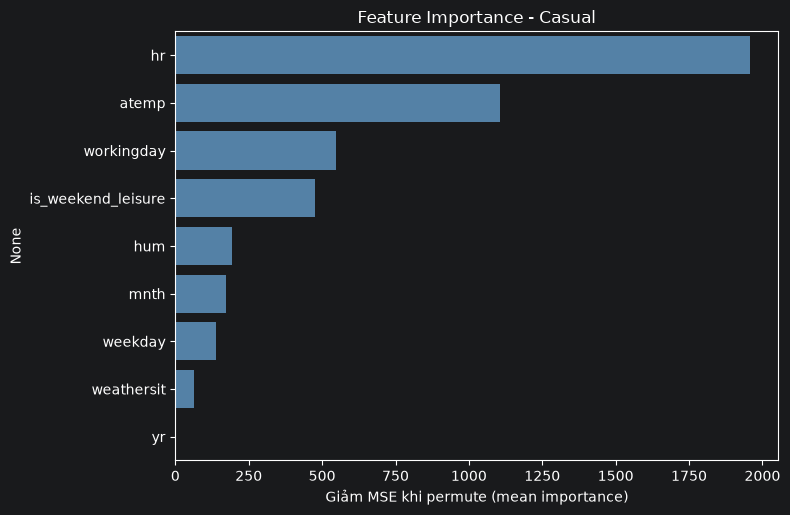

hr                    1955.981000
atemp                 1105.372015
workingday             547.569476
is_weekend_leisure     477.298859
hum                    191.430511
mnth                   173.457172
weekday                136.801337
weathersit              62.173212
yr                       0.000000
dtype: float64

In [146]:
plot_feature_importance(best_casual, X_test_casual, y_test_casual, title="Feature Importance - Casual")

In [147]:
X_train_registered = pd.read_csv("../datas/X_train_registered.csv")
y_train_registered = pd.read_csv("../datas/y_train_registered.csv").iloc[:, 0]

X_test_registered = pd.read_csv("../datas/X_test_registered.csv")
y_test_registered = pd.read_csv("../datas/y_test_registered.csv").iloc[:, 0]

In [148]:
cat_cols = ["mnth","hr","yr","weekday","workingday","is_weekend_leisure","is_rush_hour","weathersit"]

In [149]:
X_train_registered[cat_cols] = X_train_registered[cat_cols].astype("category")
X_test_registered[cat_cols] = X_test_registered[cat_cols].astype("category")

In [150]:
best_registered, result_registered, raw_results_registered = get_result_evaluate(
    X_train_registered, y_train_registered, n_splits=N_SPLITS, gap=CV_GAP
)


  Tuning: Linear Regression (Baseline)


C:\UIT\Lab\Data Analysic\Project\.venv\Lib\site-packages\sklearn\linear_model\_glm\glm.py:296: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


  Best params: {'prep__num__poly__degree': 2}
  MSE     : 5423.9068

  Tuning: Decision Tree
  Best params: {'tree__max_depth': 12, 'tree__max_features': 0.7, 'tree__min_samples_leaf': 1}
  MSE     : 5228.8287

  Tuning: Random Forest
  Best params: {'rf__max_depth': 10, 'rf__max_features': 0.7, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 300}
  MSE     : 4537.8128

  Tuning: LightGBM
  Best params: {'lgb__colsample_bytree': 0.8, 'lgb__learning_rate': 0.1, 'lgb__max_depth': 5, 'lgb__n_estimators': 300, 'lgb__num_leaves': 20, 'lgb__subsample': 0.8}
  MSE     : 3289.1202

  Tuning: XGBoost
  Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}
  MSE     : 3426.3205

  KẾT QUẢ TỔNG HỢP (sort theo MAE tăng dần)
                       Model  MSE (mean)   MSE (std)  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  R² (mean)  R2 (std)
                    LightGBM 3289.120239 1497.215650   36.343051  10.2

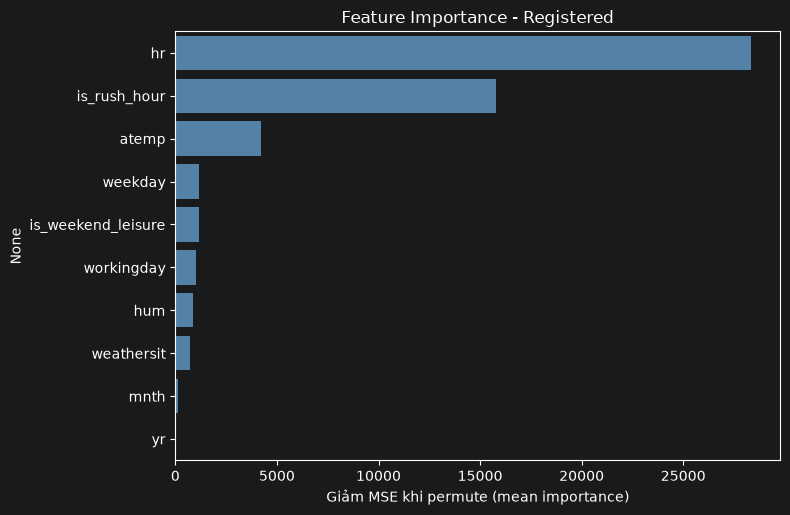

hr                    28346.786967
is_rush_hour          15778.907859
atemp                  4221.384205
weekday                1149.714990
is_weekend_leisure     1145.664527
workingday             1040.698536
hum                     890.843105
weathersit              729.982432
mnth                    126.908623
yr                        0.000000
dtype: float64

In [151]:
plot_feature_importance(best_registered, X_test_registered, y_test_registered, title="Feature Importance - Registered")

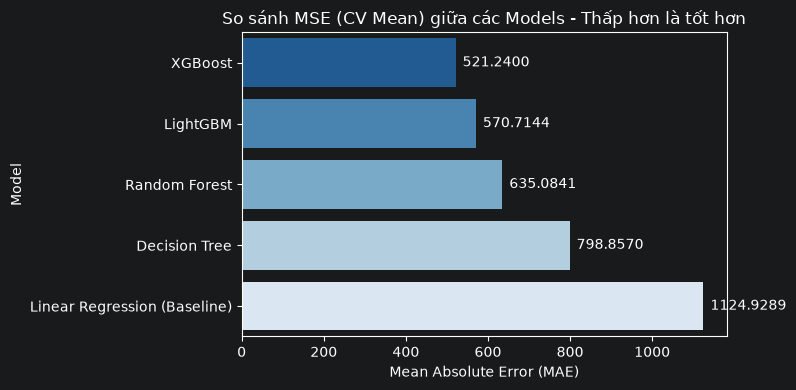

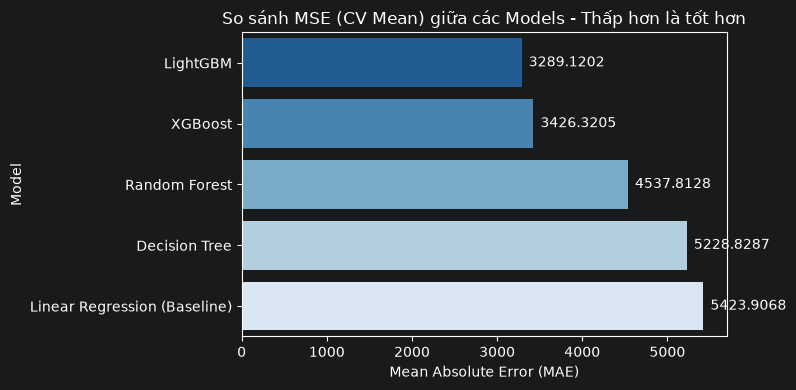

In [152]:
plot_result_evaluates(results=result_casual)
plot_result_evaluates(results=result_registered)

In [153]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_casual, "models/best_casual_rf.joblib", compress=3)
joblib.dump(best_registered, "models/best_registered_rf.joblib", compress=3)

print("Đã lưu thành công các model vào thư mục 'models/'")

Đã lưu thành công các model vào thư mục 'models/'
